# Lecture 13: Evaluating Model Outputs in Embedding Space

### Using inner products to *measure* what an AI model produces

Lecture 12 showed that meaning is geometry: text becomes vectors, and the inner
product measures similarity. Once you can embed text, you can **measure a model's
behaviour with linear algebra** instead of eyeballing it. This is Tier A #2 of
`METHODOLOGY.md` — usable today with nothing but an embedding model.

Given a set of model outputs, this lecture builds five tools, each one just
inner products and distances between unit vectors:

1. **Deduplication** — collapse near-identical answers.
2. **Clustering** — discover the distinct *modes* a model falls into.
3. **Diversity** — quantify how varied a batch of generations is.
4. **Outlier / off-topic detection** — flag answers far from the rest.
5. **Drift** — measure how far one set of outputs moved from another (e.g. two
   prompts, two model versions).

Everything here works on *any* text: model responses, customer messages,
documents. The model is a stand-in for 'a batch of generations'.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')
def embed(texts): return model.encode(texts, normalize_embeddings=True)  # unit vectors
print('ready, dim =', model.get_embedding_dimension())

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

ready, dim = 384


## A sample batch of 'model outputs'

Imagine we asked a model the same question many times and collected its answers.
The batch below deliberately contains: several genuine paraphrases, a couple of
**near-duplicates**, and one **off-topic** answer (a stand-in for a hallucination
or a derailed response).

In [2]:
outputs = [
    'A qubit is the basic unit of quantum information.',
    'The qubit is quantum computing\'s fundamental unit of information.',  # near-dup of #0
    'Unlike a bit, a qubit can be in a superposition of 0 and 1.',
    'A qubit can hold 0 and 1 at the same time through superposition.',     # near-dup of #2
    'Qubits can become entangled, correlating their measurement outcomes.',
    'Measuring a qubit collapses it to either 0 or 1.',
    'The cafeteria serves lunch from noon until two.',                      # off-topic
]
V = embed(outputs)
print('batch embeddings:', V.shape)

batch embeddings: (7, 384)


## 1. Deduplication by inner-product threshold

Two unit vectors with cosine similarity above a threshold are 'the same answer'.
We keep the first of each near-duplicate group. This is how you stop a model's
repeated generations from flooding a result set.

In [3]:
def dedupe(vecs, texts, threshold=0.85):
    keep, kept_vecs = [], []
    for i, v in enumerate(vecs):
        if all(v @ kv < threshold for kv in kept_vecs):
            keep.append(i); kept_vecs.append(v)
    return keep

keep = dedupe(V, outputs)
print(f'{len(outputs)} outputs -> {len(keep)} unique')
for i in keep: print('  kept:', outputs[i])
dropped = [i for i in range(len(outputs)) if i not in keep]
for i in dropped: print('  dropped as near-dup:', outputs[i])

7 outputs -> 5 unique
  kept: A qubit is the basic unit of quantum information.
  kept: Unlike a bit, a qubit can be in a superposition of 0 and 1.
  kept: Qubits can become entangled, correlating their measurement outcomes.
  kept: Measuring a qubit collapses it to either 0 or 1.
  kept: The cafeteria serves lunch from noon until two.
  dropped as near-dup: The qubit is quantum computing's fundamental unit of information.
  dropped as near-dup: A qubit can hold 0 and 1 at the same time through superposition.


## 2. Clustering — find the model's modes

K-means on the embeddings groups answers by meaning. Each cluster is a distinct
'thing the model said'. Useful for summarizing hundreds of generations into a
handful of themes.

In [4]:
from sklearn.cluster import KMeans

k = 4
km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(V)
for c in range(k):
    print(f'cluster {c}:')
    for i, lab in enumerate(km.labels_):
        if lab == c: print('   ', outputs[i])

cluster 0:
    Unlike a bit, a qubit can be in a superposition of 0 and 1.
    A qubit can hold 0 and 1 at the same time through superposition.
    Measuring a qubit collapses it to either 0 or 1.
cluster 1:
    The cafeteria serves lunch from noon until two.
cluster 2:
    A qubit is the basic unit of quantum information.
    The qubit is quantum computing's fundamental unit of information.
cluster 3:
    Qubits can become entangled, correlating their measurement outcomes.


## 3. Diversity of a batch

How varied is a set of generations? Average the pairwise cosine similarity: low
average similarity = high diversity. This is one number you can track when you
*want* varied outputs (brainstorming) or *want* consistency (factual answers).

In [5]:
def mean_pairwise_similarity(vecs):
    S = vecs @ vecs.T
    n = len(vecs)
    off_diag = (S.sum() - np.trace(S)) / (n * (n - 1))
    return float(off_diag)

sim = mean_pairwise_similarity(V)
print(f'mean pairwise similarity: {sim:.3f}  ->  diversity score: {1 - sim:.3f}')

# contrast: a batch of paraphrases (low diversity) vs mixed topics (high diversity)
paraphrases = embed(['A dog is a loyal pet.', 'Dogs make faithful companions.',
                      'A dog is a devoted animal friend.'])
mixed = embed(['A dog is a loyal pet.', 'Photosynthesis converts light to energy.',
               'The bond market rallied today.'])
print(f'paraphrase batch diversity: {1 - mean_pairwise_similarity(paraphrases):.3f}')
print(f'mixed-topic batch diversity: {1 - mean_pairwise_similarity(mixed):.3f}')

mean pairwise similarity: 0.507  ->  diversity score: 0.493
paraphrase batch diversity: 0.317
mixed-topic batch diversity: 0.982


## 4. Outlier / off-topic detection

The **centroid** is the average direction of the batch. An answer whose inner
product with the centroid is unusually low is an outlier — an off-topic or
derailed response. This is a cheap hallucination/derailment smoke-test.

In [6]:
centroid = V.mean(axis=0)
centroid = centroid / np.linalg.norm(centroid)
scores = V @ centroid

order = np.argsort(scores)
print('answers ranked by alignment with the batch centroid (lowest = most outlier):')
for i in order:
    flag = '  <-- OUTLIER' if scores[i] < scores.mean() - scores.std() else ''
    print(f'  {scores[i]:+.3f}  {outputs[i]}{flag}')

answers ranked by alignment with the batch centroid (lowest = most outlier):
  +0.254  The cafeteria serves lunch from noon until two.  <-- OUTLIER
  +0.784  Qubits can become entangled, correlating their measurement outcomes.
  +0.832  Measuring a qubit collapses it to either 0 or 1.
  +0.845  A qubit is the basic unit of quantum information.
  +0.854  The qubit is quantum computing's fundamental unit of information.
  +0.864  A qubit can hold 0 and 1 at the same time through superposition.
  +0.884  Unlike a bit, a qubit can be in a superposition of 0 and 1.


## 5. Drift between two sets of outputs

Suppose you change a prompt, or upgrade the model, and want to know **how much
the behaviour moved**. Embed both batches, compare their centroids (overall
shift) and their spread. A large centroid distance = a large semantic change.

In [7]:
version_a = embed([
    'A qubit is the basic unit of quantum information.',
    'Qubits use superposition to represent 0 and 1 together.',
    'Entangled qubits have correlated outcomes.',
])
version_b = embed([
    'Think of a qubit like a spinning coin, both heads and tails until it lands.',
    'A qubit is like a dimmer switch between 0 and 1, not just on/off.',
    'Qubits are spooky coins that stay linked no matter the distance.',
])

ca = version_a.mean(0); ca /= np.linalg.norm(ca)
cb = version_b.mean(0); cb /= np.linalg.norm(cb)
centroid_similarity = float(ca @ cb)
print(f'centroid similarity A vs B: {centroid_similarity:.3f}')
print(f'semantic drift (1 - sim):   {1 - centroid_similarity:.3f}')
print('(Version B uses analogies, so it drifts from the technical Version A.)')

centroid similarity A vs B: 0.747
semantic drift (1 - sim):   0.253
(Version B uses analogies, so it drifts from the technical Version A.)


### Visualizing the two batches

Projecting the embeddings to 2D with PCA (Lectures 8/4: an eigen-decomposition,
i.e. more linear algebra) lets us *see* the drift.

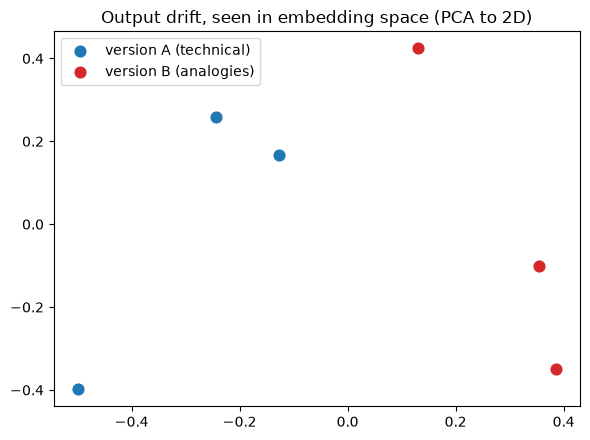

In [8]:
from sklearn.decomposition import PCA

both = np.vstack([version_a, version_b])
xy = PCA(n_components=2, random_state=0).fit_transform(both)
na = len(version_a)
plt.figure(figsize=(6, 4.5))
plt.scatter(xy[:na, 0], xy[:na, 1], c='tab:blue', s=60, label='version A (technical)')
plt.scatter(xy[na:, 0], xy[na:, 1], c='tab:red', s=60, label='version B (analogies)')
plt.title('Output drift, seen in embedding space (PCA to 2D)')
plt.legend(); plt.tight_layout(); plt.show()

## Recap

Five practical evaluation tools, all built from inner products and distances
between unit vectors — the Lecture 4 toolkit:

| Tool | The linear algebra |
|------|--------------------|
| Deduplication | pairwise inner products vs a threshold |
| Clustering | grouping vectors by direction (k-means) |
| Diversity | mean off-diagonal of $VV^\top$ |
| Outlier detection | inner product with the centroid |
| Drift | distance between batch centroids |

This is how you put numbers on otherwise-fuzzy questions like 'are the outputs
repetitive?', 'did the new prompt change the behaviour?', or 'is this answer
off-topic?' — the measurement layer of the methodology.

## Exercises

1. Lower the dedup threshold to 0.7. Which answers now merge? What is the right
   threshold for *your* tolerance?
2. Sweep `k` in the clustering and plot the inertia (elbow method) to pick the
   natural number of modes.
3. Replace the outlier rule with a fixed cutoff and turn Section 4 into a
   yes/no off-topic classifier.
4. Build a 'drift over time' plot: embed several batches and plot each centroid's
   distance from the first batch.
5. Combine with Lecture 12: use a **concept direction** instead of the centroid
   to detect drift along a *specific* axis (e.g. formality).